In [1]:
import os
print("Directorio actual:", os.getcwd())
print("Archivos en este directorio:", os.listdir())

Directorio actual: /root/tickets-mlp/model-training
Archivos en este directorio: ['training.ipynb', 'export_model', 'dataset.csv', '.ipynb_checkpoints', 'start_jupyter.sh']


### Cargado de dataset

In [2]:
import pandas as pd

df_orig = pd.read_csv("dataset.csv")
df = df_orig.copy()

df_orig

,Pabellon,Laboratorio,Categoria,Subcategoria,Afectados,Criticidad
0,Nuevo Pabellon,2,Software,No abre,2-5 PCs,Baja
1,Nuevo Pabellon,8,PC Estudiante,Falla pantalla,Mas de 5 PCs,Media
2,Nuevo Pabellon,1,Proyector,Sin imagen,No aplica,Alta
3,Nuevo Pabellon,5,Software,No abre,1 PC,Baja
4,Nuevo Pabellon,5,PC Estudiante,Falla pantalla,Mas de 5 PCs,Media
...,...,...,...,...,...,...
295,Nuevo Pabellon,8,PC Estudiante,Falla pantalla,1 PC,Baja
296,Nuevo Pabellon,3,PC Docente,Sin audio,No aplica,Media
297,Antiguo Pabellon,7,Software,No instalado,Mas de 5 PCs,Media
298,Antiguo Pabellon,3,Electricidad,Tomacorriente defectuoso,2-5 PCs,Media


### Visualizacion de datos

Antes de pasar al entrenamiento del modelo, veamos cómo está compuesto el dataset por dentro: qué tan frecuente es cada categoría, cómo se distribuye la criticidad, y si hay algún patrón visible entre ambas.

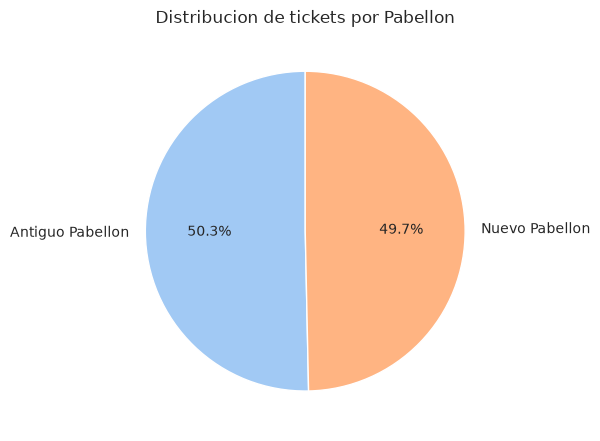

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# ============================================
# 1. Pabellon - Grafico de pie
# ============================================
plt.figure(figsize=(6, 6))
df['Pabellon'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Distribucion de tickets por Pabellon')
plt.ylabel('')
plt.tight_layout()
plt.show()

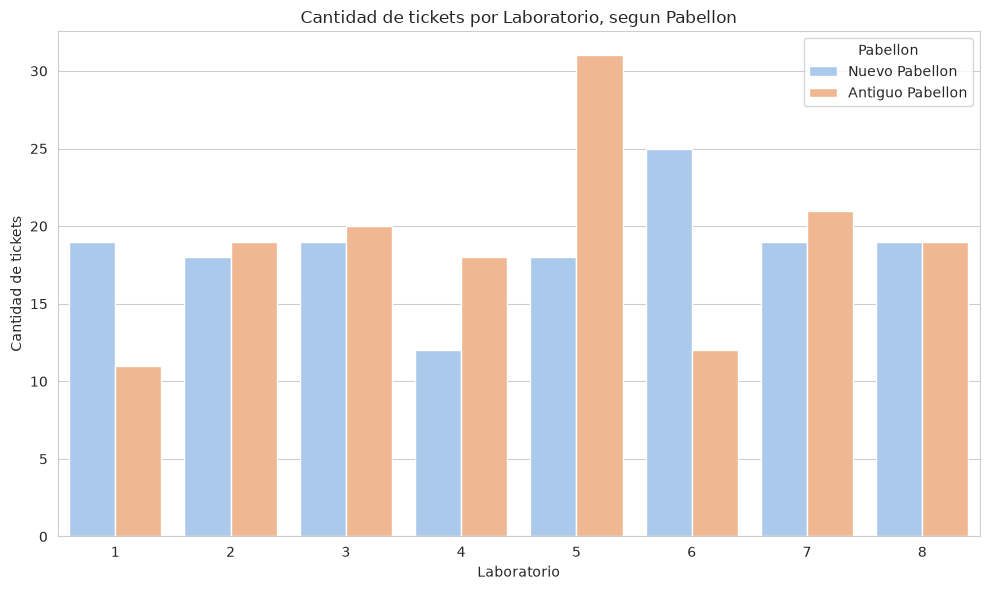

In [4]:
# ============================================
# 2. Laboratorio x Pabellon - Barras agrupadas
# ============================================
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Laboratorio', hue='Pabellon', palette='pastel')
plt.title('Cantidad de tickets por Laboratorio, segun Pabellon')
plt.xlabel('Laboratorio')
plt.ylabel('Cantidad de tickets')
plt.legend(title='Pabellon')
plt.tight_layout()
plt.show()

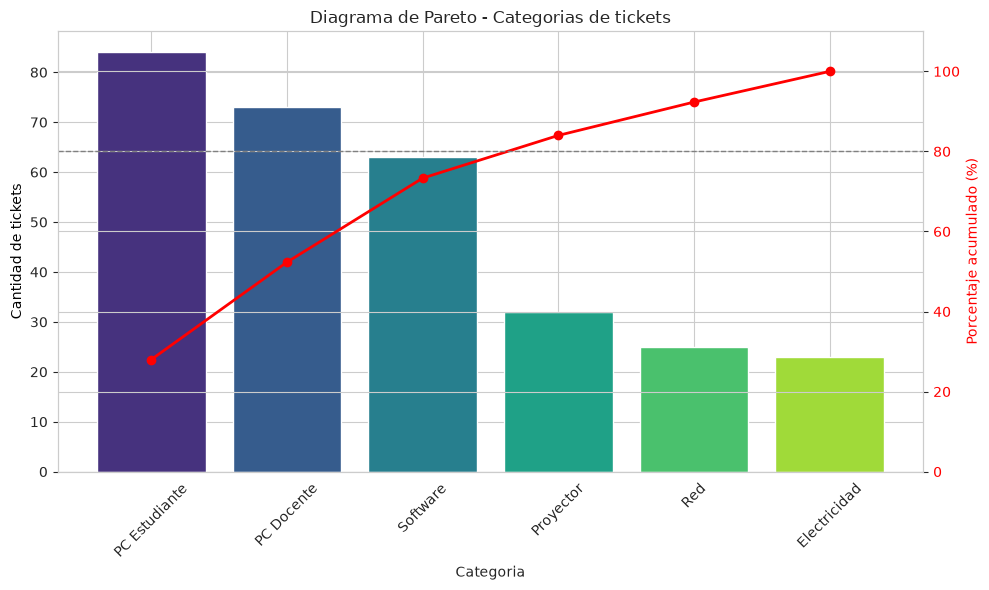

In [5]:
# ============================================
# 3. Categoria - Diagrama de Pareto de Categorias
# ============================================

conteo = df['Categoria'].value_counts().sort_values(ascending=False)
porcentaje_acumulado = conteo.cumsum() / conteo.sum() * 100
 
fig, ax1 = plt.subplots(figsize=(10, 6))
 
# Barras (cantidad de tickets por categoria, de mayor a menor)
ax1.bar(conteo.index, conteo.values, color=sns.color_palette('viridis', len(conteo)))
ax1.set_xlabel('Categoria')
ax1.set_ylabel('Cantidad de tickets', color='black')
ax1.tick_params(axis='x', rotation=45)
 
# Linea de porcentaje acumulado (eje secundario)
ax2 = ax1.twinx()
ax2.plot(conteo.index, porcentaje_acumulado.values, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Porcentaje acumulado (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)  # linea de referencia 80%
 
plt.title('Diagrama de Pareto - Categorias de tickets')
fig.tight_layout()
plt.show()

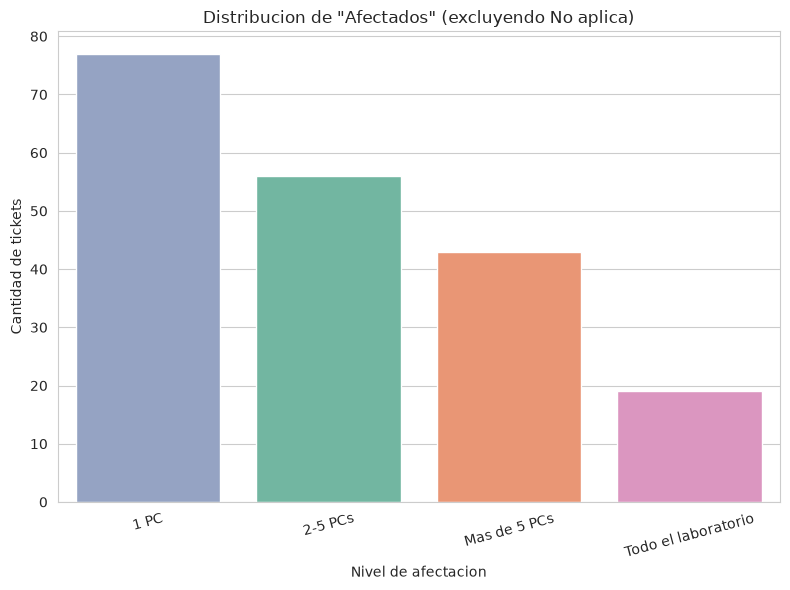

In [6]:
# ============================================
# 4. Afectados - Pie, excluyendo "No aplica"
# ============================================
plt.figure(figsize=(8, 6))
afectados_validos = df[df['Afectados'] != 'No aplica']
orden_afectados = ['1 PC', '2-5 PCs', 'Mas de 5 PCs', 'Todo el laboratorio']
sns.countplot(data=afectados_validos, x='Afectados', order=orden_afectados,
              hue='Afectados', palette='Set2', legend=False)
plt.title('Distribucion de "Afectados" (excluyendo No aplica)')
plt.xlabel('Nivel de afectacion')
plt.ylabel('Cantidad de tickets')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

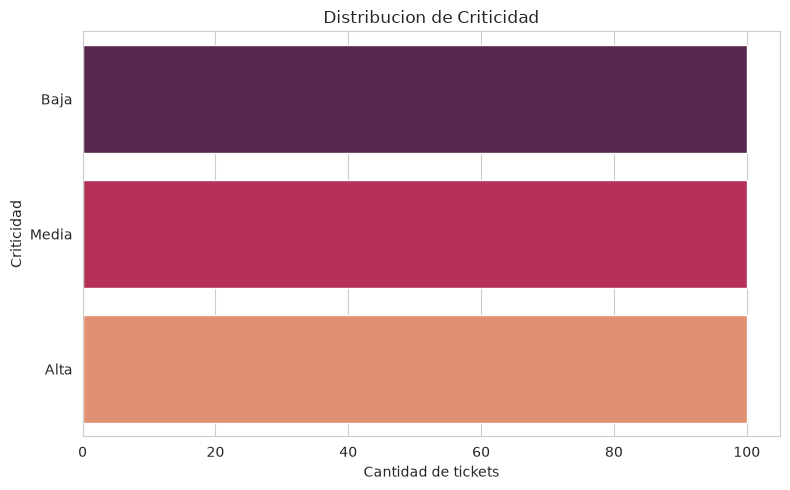

In [7]:
# ============================================
# 5. Criticidad - Grafico de barras
# ============================================
plt.figure(figsize=(8, 5))
orden_criticidad = ['Baja', 'Media', 'Alta']
sns.countplot(data=df, y='Criticidad', order=orden_criticidad, hue='Criticidad',
              palette='rocket', legend=False)
plt.title('Distribucion de Criticidad')
plt.xlabel('Cantidad de tickets')
plt.ylabel('Criticidad')
plt.tight_layout()
plt.show()

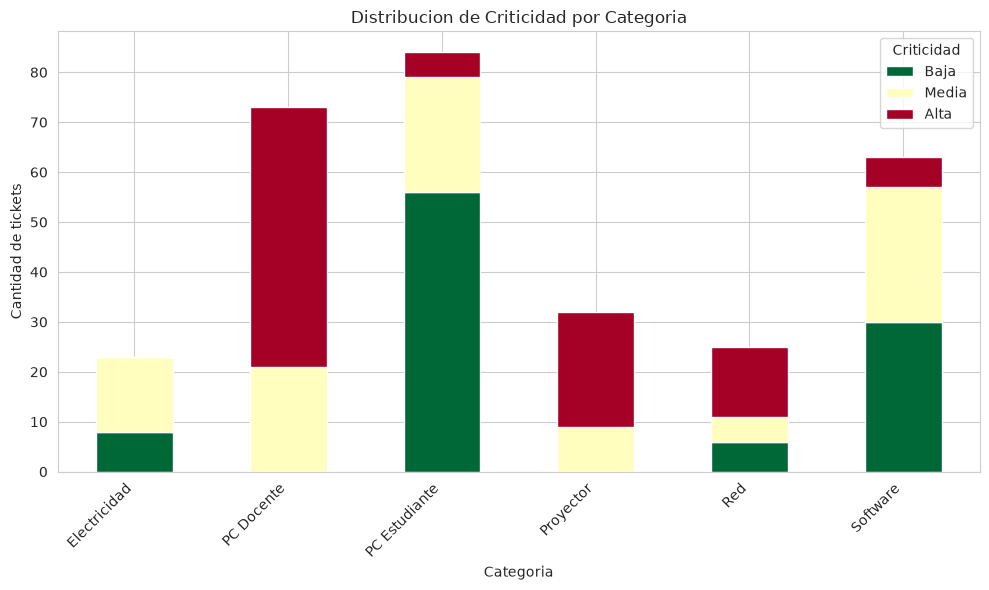

In [8]:
# ============================================
# 6. Categoria vs Criticidad - Barras apiladas
# ============================================
tabla_cruzada = pd.crosstab(df['Categoria'], df['Criticidad'])
tabla_cruzada = tabla_cruzada[['Baja', 'Media', 'Alta']]  # orden logico
tabla_cruzada.plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(10, 6))
plt.title('Distribucion de Criticidad por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Cantidad de tickets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Criticidad')
plt.tight_layout()
plt.show()

Ya vimos cómo luce el dataset. En un caso estándar, podríamos pasar directo a entrenar el modelo. 

Sin embargo, como se trata de un dataset custom, tendremos que adaptarlos para que el entrenamiento funcione correctamente.

### Tratamiento del dataset

#### Primera parte: categorias nominales

Las primeras 4 categorías del dataset son categorías nominales, es decir, no existe relación de orden entre sí (el pabellón nuevo no es "más" que el antiguo, ni el laboratorio 7 es "más" que el laboratorio 3).

Por ello, usaremos la función de one-hot encoding, para así dividir las columnas con múltiples opciones en múltiples columnas binarias (0 o 1).

In [9]:
# Nominales: one-hot encoding
columnas_nominales = ['Pabellon', 'Laboratorio', 'Categoria', 'Subcategoria']
df = pd.get_dummies(df, columns=columnas_nominales, dtype=int)
df

,Afectados,Criticidad,Pabellon_Antiguo Pabellon,Pabellon_Nuevo Pabellon,Laboratorio_1,Laboratorio_2,Laboratorio_3,Laboratorio_4,Laboratorio_5,Laboratorio_6,...,Subcategoria_No abre,Subcategoria_No enciende,Subcategoria_No instalado,Subcategoria_Pantalla negra,Subcategoria_Presenta errores,Subcategoria_Sin Internet,Subcategoria_Sin audio,Subcategoria_Sin energia,Subcategoria_Sin imagen,Subcategoria_Tomacorriente defectuoso
0,2-5 PCs,Baja,0,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,Mas de 5 PCs,Media,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,No aplica,Alta,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1 PC,Baja,0,1,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
4,Mas de 5 PCs,Media,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1 PC,Baja,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
296,No aplica,Media,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
297,Mas de 5 PCs,Media,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
298,2-5 PCs,Media,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


#### Segunda parte: categorias ordinales

Para la segunda parte, ya no tenemos una categoría nominal, sino ordinal, donde sí existe una sucesión lógica (que todo el laboratorio esté afectado representa una mayor gravedad que tener solo de 2 a 5 PCs fallando).

Por ello, crearemos dos nuevas columnas: una binaria que indique si el campo "Afectados" aplica o no para esa fila (ya que en categorías como PC Docente o Proyector no corresponde), y otra que codifique numéricamente el nivel de afectación respetando su orden real (1 PC < 2-5 PCs < Más de 5 PCs < Todo el laboratorio).

In [10]:
# Columna que indica si el campo Afectados es relevante para esa fila
df['Aplica_Afectados'] = (df['Afectados'] != 'No aplica').astype(int)

# Mapeo ordinal SOLO con los valores reales (sin "No aplica")
afectados_map = {
    "1 PC": 0,
    "2-5 PCs": 1,
    "Mas de 5 PCs": 2,
    "Todo el laboratorio": 3
}

# Para las filas donde no aplica, usamos un valor neutro (ej. 0)
df['Afectados_ordinal'] = df['Afectados'].map(afectados_map).fillna(0).astype(int)

df[['Afectados', 'Aplica_Afectados', 'Afectados_ordinal']]

,Afectados,Aplica_Afectados,Afectados_ordinal
0,2-5 PCs,1,1
1,Mas de 5 PCs,1,2
2,No aplica,0,0
3,1 PC,1,0
4,Mas de 5 PCs,1,2
...,...,...,...
295,1 PC,1,0
296,No aplica,0,0
297,Mas de 5 PCs,1,2
298,2-5 PCs,1,1


In [11]:
# Eliminar la columna original de texto 'Afectados' (ya no la necesitamos)
df = df.drop(columns=['Afectados'])

#### Tercera parte: variable objetivo (target)

Finalmente, la columna Criticidad es nuestra variable objetivo (target), la que el modelo deberá aprender a predecir. Al igual que "Afectados", esta columna también es ordinal, ya que existe una jerarquía clara de gravedad: Baja < Media < Alta.

Por ello, la codificaremos como valores numéricos que respeten ese orden, comenzando desde 0 (convención estándar al trabajar con librerías de clasificación como scikit-learn o Keras/TensorFlow).

In [12]:
criticidad_map = {
    "Baja": 0,
    "Media": 1,
    "Alta": 2
}

df['Criticidad'] = df['Criticidad'].map(criticidad_map)
df

,Criticidad,Pabellon_Antiguo Pabellon,Pabellon_Nuevo Pabellon,Laboratorio_1,Laboratorio_2,Laboratorio_3,Laboratorio_4,Laboratorio_5,Laboratorio_6,Laboratorio_7,...,Subcategoria_No instalado,Subcategoria_Pantalla negra,Subcategoria_Presenta errores,Subcategoria_Sin Internet,Subcategoria_Sin audio,Subcategoria_Sin energia,Subcategoria_Sin imagen,Subcategoria_Tomacorriente defectuoso,Aplica_Afectados,Afectados_ordinal
0,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
2,2,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
296,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
297,1,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,1,2
298,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1


Ahora que ya logramos adaptar el modelo, estamos listos para empezar el entrenamiento

### Entrenamiento del modelo

Con el dataset ya transformado a un formato numérico, pasamos a la etapa de entrenamiento. 

Esto implica separar los datos en conjuntos de entrenamiento y prueba, escalar las variables, entrenar el Perceptrón Multicapa y finalmente evaluar qué tan bien aprendió a clasificar la criticidad de los tickets.

#### Division de X (variables independientes) e y (variable dependiente u objetivo)

In [13]:
from sklearn.model_selection import train_test_split

# X = todas las columnas EXCEPTO Criticidad (el target)
X = df.drop(columns=['Criticidad'])

# y = solo la columna que queremos predecir
y = df['Criticidad']

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (300, 33)
Forma de y: (300,)


#### Division de dataset en train y test

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para test, 80% para entrenamiento
    random_state=42,     # semilla fija, para que el split sea reproducible
    stratify=y           # mantiene la misma proporción de cada clase
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (240, 33) (240,)
Prueba: (60, 33) (60,)


In [15]:
# Verificamos que el split quedó balanceado gracias al stratify

print("Distribucion en train:")
print(y_train.value_counts(normalize=True))

print("\nDistribucion en test:")
print(y_test.value_counts(normalize=True))

Distribucion en train:
Criticidad
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

Distribucion en test:
Criticidad
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


#### Escalado de features

Antes de entrenar, hay un detalle: los MLPs son sensibles a la escala de los datos. Si bien la columna Afectados_ordinal va de 0 a 3, todas las demas columnas one-hot son 0 o 1. 

Si bien no es una diferencia enorme, por buenas prácticas escalaremos todo al mismo rango para que el modelo entrene mejor y más rápido.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Entrenamiento del Perceptron Multicapa

Entrenamos un MLP con dos capas ocultas (16 y 8 neuronas), usando ReLU como función de activación y Adam como optimizador. Dado el tamaño reducido del dataset, se optó por una arquitectura simple para evitar sobreajuste.

In [17]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),   # 2 capas ocultas: 16 neuronas, luego 8
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


#### Evaluacion del modelo

Luego del entrenamiento, pasamos a la evaluación del modelo con el conjunto de prueba. Se revisará tanto la precisión, como el recall y F1-score por clase, además del accuracy general. 

Aunque el dataset está balanceado entre las tres categorías de criticidad, estas métricas por clase permiten identificar si el modelo tiene dificultades particulares para distinguir alguna de ellas. 

También se incluye la matriz de confusión para visualizar en qué clases el modelo tiende a confundirse.

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['Baja', 'Media', 'Alta']))

              precision    recall  f1-score   support

        Baja       0.91      1.00      0.95        20
       Media       1.00      0.80      0.89        20
        Alta       0.91      1.00      0.95        20

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



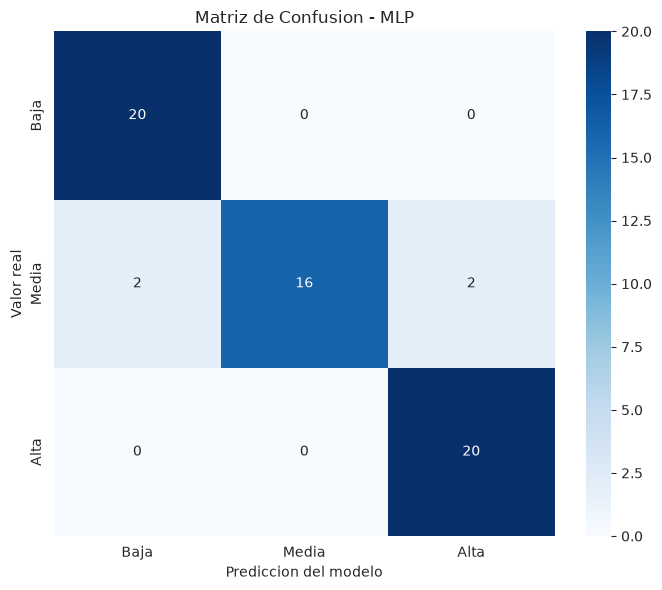

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,           # muestra los numeros dentro de cada celda
    fmt='d',               # formato entero (sin decimales)
    cmap='Blues',
    xticklabels=['Baja', 'Media', 'Alta'],
    yticklabels=['Baja', 'Media', 'Alta']
)
plt.xlabel('Prediccion del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de Confusion - MLP')
plt.tight_layout()
plt.show()